In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

True

## SubGraph

In [2]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [3]:
parent_llm = ChatOpenAI(model='gpt-4o-mini')
subgraph_llm = ChatOpenAI(model='gpt-4o')

In [4]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [5]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

## ParentGraph

In [6]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [7]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

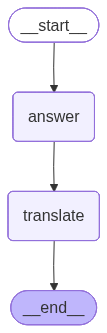

In [8]:
graph = parent_builder.compile()

graph

In [9]:
graph.invoke({'question': 'Who is Virat Kholi'})

{'question': 'Who is Virat Kholi',
 'answer_eng': 'Virat Kohli is an Indian cricketer and one of the most prominent figures in international cricket. Born on November 5, 1988, in Delhi, India, he is known for his aggressive batting style and remarkable consistency as a batsman. Kohli has served as the captain of the Indian national team in all three formats of the game: Test, One Day Internationals (ODIs), and Twenty20 Internationals (T20Is). \n\nHe is a former captain of the Royal Challengers Bangalore (RCB) in the Indian Premier League (IPL). Kohli has received numerous awards for his performances, including the ICC ODI Player of the Year and several other accolades. He is also known for his philanthropic efforts and is one of the most marketable athletes globally.',
 'answer_hin': 'विराट कोहली एक भारतीय क्रिकेटर हैं और अंतरराष्ट्रीय क्रिकेट में सबसे प्रमुख व्यक्तित्वों में से एक हैं। 5 नवंबर 1988 को दिल्ली, भारत में जन्मे कोहली अपनी आक्रामक बल्लेबाजी शैली और बल्लेबाज के रूप में अद्भ